# 01 — Pipeline Big Data, Dask y calidad de datos

Este notebook explica el pipeline batch/online: ingesta, validación, transformación, carga, eventos, Dask, rechazos y alertas de calidad.

In [1]:
from pathlib import Path
import ast
import json
import os
import subprocess
import textwrap
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


# =============================================================================
# 0. Utilidades base del notebook
# =============================================================================

FENCE = "`" * 3


def md(text: str) -> None:
    """Renderiza Markdown de forma cómoda."""
    display(Markdown(textwrap.dedent(text).strip()))


def code_block(lang: str, text: str) -> None:
    """Renderiza un bloque de código dentro de Markdown sin romper la celda Python."""
    display(Markdown(f"{FENCE}{lang}\n{textwrap.dedent(text).strip()}\n{FENCE}"))


def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto localizando docker-compose.yml."""
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]

    for candidate in candidates:
        if (candidate / "docker-compose.yml").exists():
            return candidate

    return start


ROOT = find_project_root()
print(f"ROOT = {ROOT}")


def read_json(path: Path, default=None):
    """Lee un JSON de forma segura."""
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}")
        return default

    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as exc:
        print(f"[error] No se pudo leer {path}: {exc}")
        return default


def read_text(path: Path, default: str = "") -> str:
    """Lee texto de forma segura."""
    path = Path(path)
    if not path.exists():
        return default

    try:
        return path.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        return default


def read_env(path: Path) -> dict:
    """Lee variables de entorno simples desde .env."""
    env = {}
    path = Path(path)

    if not path.exists():
        return env

    for raw in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue

        k, v = line.split("=", 1)
        env[k.strip()] = v.strip().strip('"').strip("'")

    return env


def run_cmd(cmd: str, timeout: int = 60) -> str:
    """Ejecuta un comando shell y devuelve stdout/stderr como texto."""
    print(f"$ {cmd}")

    try:
        result = subprocess.run(
            cmd,
            shell=True,
            cwd=ROOT,
            text=True,
            capture_output=True,
            timeout=timeout,
        )

        if result.stdout:
            print(result.stdout)

        if result.stderr:
            print(result.stderr)

        print(f"exit_code={result.returncode}")
        return (result.stdout or "") + (result.stderr or "")

    except Exception as exc:
        print(f"[error] {exc}")
        return str(exc)


def show_bar(series, title: str, ylabel: str = "valor"):
    """Pinta una barra simple desde Series/dict."""
    ax = pd.Series(series).plot(kind="bar")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


def file_size_kb(path: Path) -> float | None:
    try:
        return round(path.stat().st_size / 1024, 2)
    except Exception:
        return None


def line_count(path: Path) -> int | None:
    try:
        return len(path.read_text(encoding="utf-8", errors="ignore").splitlines())
    except Exception:
        return None


def extract_docstring(path: Path) -> str:
    """Extrae docstring principal de un .py."""
    try:
        source = path.read_text(encoding="utf-8", errors="ignore")
        tree = ast.parse(source)
        doc = ast.get_docstring(tree) or ""
        return " ".join(doc.strip().split())
    except Exception:
        return ""


def extract_public_functions(path: Path) -> list[str]:
    """Lista funciones públicas de un .py."""
    try:
        source = path.read_text(encoding="utf-8", errors="ignore")
        tree = ast.parse(source)

        functions = []
        for node in ast.walk(tree):
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
                if not node.name.startswith("_"):
                    functions.append(node.name)

        return sorted(set(functions))
    except Exception:
        return []


def short_text(text: str, max_len: int = 260) -> str:
    text = " ".join(str(text).split())
    if len(text) <= max_len:
        return text
    return text[:max_len] + "..."


pipeline_root = ROOT / "services" / "pipeline"


# =============================================================================
# 1. Introducción
# =============================================================================

md("""
# 01 — Pipeline Big Data

Este notebook explica el módulo `services/pipeline`, que implementa el flujo de datos principal del sistema hospitalario.

El pipeline convierte datos crudos en información validada, almacenada, monitorizada y disponible para la API, el dashboard y los modelos de IA.
""")

requirements_df = pd.DataFrame([
    {
        "requisito del enunciado": "Ingesta automatizada",
        "implementación": "CSV batch desde MinIO/S3 y fichas online desde API/dashboard",
        "evidencia": "`main.py seed`, `main.py batch`, `POST /patients`, `POST /batch-runs`",
    },
    {
        "requisito del enunciado": "Almacenamiento combinado",
        "implementación": "MinIO para raw, PostgreSQL para datos estructurados, MongoDB para eventos/rechazos/predicciones",
        "evidencia": "`raw_source.py`, `postgres.py`, `mongo.py`",
    },
    {
        "requisito del enunciado": "Procesamiento escalable",
        "implementación": "Dask scheduler + worker + lectura escalable de CSV",
        "evidencia": "`dask_runtime.py`, `scalable_csv.py`, dashboard Dask `localhost:8787`",
    },
    {
        "requisito del enunciado": "Servicio de datos",
        "implementación": "API REST y dashboard Streamlit consumen datos procesados",
        "evidencia": "`services/api`, `services/dashboard`",
    },
    {
        "requisito del enunciado": "Calidad de datos",
        "implementación": "Reglas declarativas en `validation_rules.yaml`",
        "evidencia": "`validation.py`, `ingestion_rejects`, eventos `pipeline.validation.done`",
    },
    {
        "requisito del enunciado": "Logging centralizado",
        "implementación": "Logs JSON + Promtail + Loki",
        "evidencia": "`logging_setup.py`, `monitoring/promtail-config.yaml`, `monitoring/loki-config.yaml`",
    },
    {
        "requisito del enunciado": "Alertas",
        "implementación": "Servicio `automation` revisa `system_events` y crea documentos en `alerts`",
        "evidencia": "`services/automation/main.py`",
    },
])

display(requirements_df)


# =============================================================================
# 2. Inventario completo de archivos
# =============================================================================

md("""
## 1. Inventario completo del módulo `services/pipeline`

Esta tabla explica para qué sirve cada archivo del pipeline. No es solo un listado de ficheros: muestra su capa dentro de la arquitectura, su propósito, por qué importa, tamaño y funciones públicas detectadas.
""")

if not pipeline_root.exists():
    md(f"❌ No existe `{pipeline_root}`.")
else:
    known_purposes = {
        "main.py": {
            "capa": "Entrada / CLI",
            "propósito": (
                "Punto de entrada del servicio pipeline. Permite ejecutar comandos operativos "
                "desde Docker, por ejemplo generar datos sintéticos o procesar un CSV batch."
            ),
            "por_qué_importa": (
                "Hace el pipeline reproducible desde consola y desde contenedor, sin depender del dashboard."
            ),
        },
        "requirements.txt": {
            "capa": "Dependencias",
            "propósito": "Lista librerías necesarias para ejecutar el pipeline.",
            "por_qué_importa": "Permite construir la imagen Docker del servicio con dependencias controladas.",
        },
        "app/__init__.py": {
            "capa": "Paquete Python",
            "propósito": "Marca `app/` como paquete Python.",
            "por_qué_importa": "Permite imports internos limpios.",
        },
        "app/config.py": {
            "capa": "Configuración",
            "propósito": (
                "Centraliza variables de configuración: PostgreSQL, MongoDB, MinIO/S3, Dask, "
                "nombre de servicio y parámetros del pipeline."
            ),
            "por_qué_importa": (
                "Evita hardcodear credenciales o endpoints y permite configurar mediante `.env` y Docker Compose."
            ),
        },
        "app/orchestrator.py": {
            "capa": "Orquestación batch",
            "propósito": (
                "Coordina el flujo batch completo: ingesta, validación, transformación, carga, "
                "llamada a ML, agregados y eventos."
            ),
            "por_qué_importa": (
                "Es el núcleo del pipeline batch. Define el orden de las fases y construye el resumen final."
            ),
        },
        "app/online.py": {
            "capa": "Orquestación online",
            "propósito": (
                "Procesa una ficha individual procedente del formulario del dashboard/API usando la misma lógica "
                "de validación, transformación, carga y predicción."
            ),
            "por_qué_importa": (
                "Permite reutilizar el pipeline para el caso online, no solo para lotes CSV."
            ),
        },
        "app/events.py": {
            "capa": "Eventos de dominio",
            "propósito": (
                "Persiste eventos funcionales en MongoDB (`system_events`) y también los emite a logs técnicos."
            ),
            "por_qué_importa": (
                "Permite reconstruir un run completo por `correlation_id`, alimentar timelines y generar alertas."
            ),
        },
        "app/logging_setup.py": {
            "capa": "Logging",
            "propósito": (
                "Configura logs JSON a stdout con campos como `ts`, `level`, `service`, "
                "`correlation_id`, `event` y `message`."
            ),
            "por_qué_importa": (
                "Los logs estructurados pueden ser recogidos por Promtail y centralizados en Loki."
            ),
        },
        "app/dask_runtime.py": {
            "capa": "Procesamiento escalable",
            "propósito": "Gestiona la conexión del pipeline al scheduler de Dask.",
            "por_qué_importa": "Demuestra que el pipeline está preparado para procesamiento distribuible/escalable.",
        },
        "app/clients/__init__.py": {
            "capa": "Clientes externos",
            "propósito": "Marca `clients/` como paquete Python.",
            "por_qué_importa": "Agrupa clientes HTTP hacia otros microservicios.",
        },
        "app/clients/triage_client.py": {
            "capa": "Cliente ML",
            "propósito": (
                "Cliente HTTP hacia `ml-triage`. Envía fichas validadas y recibe predicciones "
                "de triaje y sospecha de enfermedad."
            ),
            "por_qué_importa": (
                "Mantiene separación de responsabilidades: el pipeline no implementa el modelo, solo lo consume."
            ),
        },
        "app/phases/__init__.py": {
            "capa": "Fases ETL",
            "propósito": "Marca `phases/` como paquete Python.",
            "por_qué_importa": "Agrupa las fases del pipeline por responsabilidad.",
        },
        "app/phases/ingestion.py": {
            "capa": "Fase 1 — Ingesta",
            "propósito": "Lee ficheros CSV desde `RawSource`, normalmente MinIO/S3, y produce un DataFrame.",
            "por_qué_importa": "Es la entrada batch del pipeline. Registra filas leídas y metadatos de lectura.",
        },
        "app/phases/scalable_csv.py": {
            "capa": "Fase 1b — Lectura escalable",
            "propósito": "Implementa lectura escalable/particionada de CSV, integrando Dask cuando está configurado.",
            "por_qué_importa": "Es la pieza que justifica el uso de un framework escalable como Dask.",
        },
        "app/phases/validation.py": {
            "capa": "Fase 2 — Validación",
            "propósito": (
                "Aplica reglas declarativas del YAML: campos obligatorios, tipos, rangos, enums "
                "y reglas cruzadas."
            ),
            "por_qué_importa": "Cubre calidad de datos y separa válidos de rechazados.",
        },
        "app/phases/transformation.py": {
            "capa": "Fase 3 — Transformación",
            "propósito": "Convierte filas válidas en estructuras normalizadas de paciente e ingreso.",
            "por_qué_importa": "Separa el CSV de entrada del modelo de datos estructurado del hospital.",
        },
        "app/phases/loading.py": {
            "capa": "Fase 4 — Carga",
            "propósito": (
                "Inserta pacientes e ingresos en PostgreSQL y guarda rechazos/predicciones/eventos relacionados "
                "en MongoDB."
            ),
            "por_qué_importa": "Materializa el resultado del pipeline en almacenamiento persistente.",
        },
        "app/phases/aggregates.py": {
            "capa": "Fase 5 — Agregados",
            "propósito": (
                "Actualiza agregados diarios con métricas de ejecución: registros leídos, válidos, rechazados, "
                "insertados, triaje completado, etc."
            ),
            "por_qué_importa": "Permite mostrar métricas operativas y evolución en dashboard.",
        },
        "app/storage/__init__.py": {
            "capa": "Almacenamiento",
            "propósito": "Marca `storage/` como paquete Python.",
            "por_qué_importa": "Agrupa conectores de almacenamiento.",
        },
        "app/storage/raw_source.py": {
            "capa": "Almacenamiento raw",
            "propósito": "Abstrae el origen raw de datos. En el proyecto se usa principalmente MinIO/S3.",
            "por_qué_importa": "Permite leer datos crudos desde una landing zone S3-compatible, patrón habitual Big Data.",
        },
        "app/storage/postgres.py": {
            "capa": "Almacenamiento estructurado",
            "propósito": "Gestiona conexión y operaciones contra PostgreSQL.",
            "por_qué_importa": "PostgreSQL guarda entidades estructuradas y relacionales como pacientes e ingresos.",
        },
        "app/storage/mongo.py": {
            "capa": "Almacenamiento documental",
            "propósito": "Gestiona conexión y colecciones MongoDB: eventos, rechazos, predicciones, agregados y alertas.",
            "por_qué_importa": "MongoDB permite persistir documentos flexibles con outputs heterogéneos de modelos y eventos.",
        },
        "app/utils/__init__.py": {
            "capa": "Utilidades",
            "propósito": "Marca `utils/` como paquete Python si existe.",
            "por_qué_importa": "Permite agrupar funciones auxiliares.",
        },
        "config/validation_rules.yaml": {
            "capa": "Calidad de datos",
            "propósito": "Define reglas declarativas de validación para la entidad paciente.",
            "por_qué_importa": "Permite modificar reglas de calidad sin tocar código Python.",
        },
        "seed/__init__.py": {
            "capa": "Datos sintéticos",
            "propósito": "Marca `seed/` como paquete Python.",
            "por_qué_importa": "Agrupa generación de datos reproducibles.",
        },
        "seed/generate_fichas.py": {
            "capa": "Datos sintéticos",
            "propósito": "Genera fichas de pacientes sintéticas para pruebas batch.",
            "por_qué_importa": "Permite probar el sistema sin datos clínicos reales.",
        },
    }

    all_files = sorted([p for p in pipeline_root.rglob("*") if p.is_file()])

    inventory_rows = []

    for path in all_files:
        rel = str(path.relative_to(pipeline_root)).replace("\\", "/")
        known = known_purposes.get(rel, {})

        doc = extract_docstring(path) if path.suffix == ".py" else ""
        funcs = extract_public_functions(path) if path.suffix == ".py" else []

        inventory_rows.append({
            "archivo": rel,
            "capa": known.get("capa", "No documentado explícitamente"),
            "propósito": known.get("propósito", short_text(doc, 240) if doc else "Archivo auxiliar o generado."),
            "por qué importa": known.get("por_qué_importa", "Forma parte del módulo pipeline."),
            "líneas": line_count(path),
            "tamaño_kb": file_size_kb(path),
            "funciones públicas detectadas": ", ".join(funcs[:10]),
        })

    inventory_df = pd.DataFrame(inventory_rows)
    display(inventory_df)


# =============================================================================
# 3. Estructura funcional por carpetas
# =============================================================================

md("""
## 2. Estructura funcional de carpetas

Esta tabla resume cómo está dividido el módulo. El objetivo es demostrar separación de responsabilidades.
""")

folder_explanation = pd.DataFrame([
    {
        "carpeta": "services/pipeline/",
        "qué contiene": "Código del pipeline batch y online.",
        "función": "Procesar datos clínicos desde la entrada cruda hasta almacenamiento, ML, eventos y agregados.",
    },
    {
        "carpeta": "services/pipeline/app/",
        "qué contiene": "Código principal de aplicación.",
        "función": "Configuración, orquestación, eventos, logging y runtime Dask.",
    },
    {
        "carpeta": "services/pipeline/app/clients/",
        "qué contiene": "Clientes HTTP hacia otros servicios.",
        "función": "Comunicar el pipeline con `ml-triage` sin acoplar código del modelo.",
    },
    {
        "carpeta": "services/pipeline/app/phases/",
        "qué contiene": "Fases ETL separadas.",
        "función": "Ingesta, validación, transformación, carga, lectura escalable y agregados.",
    },
    {
        "carpeta": "services/pipeline/app/storage/",
        "qué contiene": "Conectores de almacenamiento.",
        "función": "Abstraer MinIO/S3, PostgreSQL y MongoDB.",
    },
    {
        "carpeta": "services/pipeline/config/",
        "qué contiene": "Reglas YAML.",
        "función": "Declarar calidad de datos sin modificar Python.",
    },
    {
        "carpeta": "services/pipeline/seed/",
        "qué contiene": "Generación de datos sintéticos.",
        "función": "Crear CSVs de prueba reproducibles para demos y validación.",
    },
])

display(folder_explanation)


# =============================================================================
# 4. Fases del pipeline
# =============================================================================

md("""
## 3. Fases del pipeline: qué entra, qué ocurre y qué sale

El pipeline está dividido en fases explícitas. Esto facilita explicar, probar y depurar cada parte.
""")

pipeline_phases = pd.DataFrame([
    {
        "orden": 1,
        "fase": "Ingesta",
        "archivo principal": "app/phases/ingestion.py",
        "entrada": "CSV crudo almacenado en MinIO/S3 o subido desde API/dashboard.",
        "proceso": "Abre el objeto raw y lo convierte en DataFrame.",
        "salida": "DataFrame crudo + metadatos de lectura.",
        "evento": "pipeline.file.read",
    },
    {
        "orden": 2,
        "fase": "Lectura escalable",
        "archivo principal": "app/phases/scalable_csv.py + app/dask_runtime.py",
        "entrada": "CSV potencialmente grande.",
        "proceso": "Usa Dask para lectura particionada cuando `PIPELINE_PROCESSING_ENGINE=dask`.",
        "salida": "DataFrame materializado y metadatos de Dask.",
        "evento": "app.dask_runtime / pipeline.file.read",
    },
    {
        "orden": 3,
        "fase": "Validación",
        "archivo principal": "app/phases/validation.py + config/validation_rules.yaml",
        "entrada": "DataFrame crudo.",
        "proceso": "Comprueba campos obligatorios, tipos, rangos, enums y reglas cruzadas.",
        "salida": "DataFrame válido + DataFrame de rechazos.",
        "evento": "pipeline.validation.done",
    },
    {
        "orden": 4,
        "fase": "Transformación",
        "archivo principal": "app/phases/transformation.py",
        "entrada": "Filas válidas.",
        "proceso": "Genera entidades normalizadas: paciente e ingreso.",
        "salida": "Listas `pacientes_rows` e `ingresos_rows`.",
        "evento": "pipeline.transformation.done",
    },
    {
        "orden": 5,
        "fase": "Carga",
        "archivo principal": "app/phases/loading.py",
        "entrada": "Pacientes, ingresos y rechazos.",
        "proceso": "Inserta datos válidos en PostgreSQL y rechazos en MongoDB.",
        "salida": "Tablas SQL + colección `ingestion_rejects`.",
        "evento": "pipeline.loading.done / pipeline.rejects.persisted",
    },
    {
        "orden": 6,
        "fase": "Inferencia tabular",
        "archivo principal": "app/clients/triage_client.py",
        "entrada": "Ficha clínica normalizada.",
        "proceso": "Llama a `ml-triage:8002/predict`.",
        "salida": "Triaje y sospecha de enfermedad.",
        "evento": "pipeline.ml.done",
    },
    {
        "orden": 7,
        "fase": "Agregados",
        "archivo principal": "app/phases/aggregates.py",
        "entrada": "Resumen del batch.",
        "proceso": "Actualiza contadores diarios.",
        "salida": "Documento agregado en MongoDB.",
        "evento": "pipeline.aggregates.updated",
    },
    {
        "orden": 8,
        "fase": "Eventos y logging",
        "archivo principal": "app/events.py + app/logging_setup.py",
        "entrada": "Estado de cada fase.",
        "proceso": "Persiste eventos en MongoDB y emite logs JSON.",
        "salida": "`system_events` + logs centralizados por Loki.",
        "evento": "pipeline.run.start / pipeline.run.end",
    },
])

display(pipeline_phases)


# =============================================================================
# 5. Diagrama del flujo completo
# =============================================================================

md("""
## 4. Flujo lógico end-to-end

El siguiente diagrama muestra cómo viajan los datos desde la entrada hasta la visualización final.
""")

code_block("text", """
Entrada batch CSV / formulario online
        │
        ▼
MinIO / RawSource
        │
        ▼
Ingestion
  - abre CSV
  - registra filas leídas
        │
        ▼
Dask runtime / scalable_csv
  - lectura particionada
  - scheduler + worker
        │
        ▼
Validation
  - required_fields
  - tipos
  - rangos
  - enums
  - reglas cruzadas
        │
        ├── rechazados ─────────────► MongoDB.ingestion_rejects
        │
        ▼
Transformation
  - paciente
  - ingreso
  - pseudo_id
        │
        ▼
Loading
  - PostgreSQL.pacientes
  - PostgreSQL.ingresos
        │
        ▼
ml-triage
  - clasificación Alta / Media / Baja
  - sospecha de enfermedad
        │
        ▼
MongoDB.predictions_triage
MongoDB.predictions_disease
        │
        ▼
Aggregates
  - MongoDB.aggregates_daily
        │
        ▼
API + Dashboard

Durante todo el proceso:
  - logs JSON a stdout
  - eventos en MongoDB.system_events
  - Promtail recoge logs
  - Loki centraliza
  - automation crea alertas si hay warning/error
""")


# =============================================================================
# 6. Almacenamiento
# =============================================================================

md("""
## 5. Almacenamiento usado por el pipeline

El pipeline usa varias tecnologías porque cada una cumple un rol distinto dentro de la arquitectura.
""")

storage_df = pd.DataFrame([
    {
        "almacenamiento": "MinIO / S3-compatible",
        "archivo": "app/storage/raw_source.py",
        "qué guarda": "CSV crudos, JSON raw de fichas online y potencialmente imágenes.",
        "papel": "Landing zone / capa raw.",
        "motivo técnico": "Permite conservar entrada original y repetir el procesamiento.",
    },
    {
        "almacenamiento": "PostgreSQL",
        "archivo": "app/storage/postgres.py",
        "qué guarda": "Pacientes e ingresos validados y normalizados.",
        "papel": "Base estructurada relacional.",
        "motivo técnico": "Integridad, SQL, relaciones y consultas operativas.",
    },
    {
        "almacenamiento": "MongoDB",
        "archivo": "app/storage/mongo.py",
        "qué guarda": "Eventos, rechazos, predicciones, agregados y alertas.",
        "papel": "Base documental flexible.",
        "motivo técnico": "Admite documentos heterogéneos de ML y trazabilidad.",
    },
    {
        "almacenamiento": "Loki",
        "archivo": "monitoring/loki-config.yaml",
        "qué guarda": "Logs técnicos de contenedores.",
        "papel": "Observabilidad.",
        "motivo técnico": "Centraliza logs del pipeline y otros servicios.",
    },
])

display(storage_df)


# =============================================================================
# 7. Dask
# =============================================================================

md("""
## 6. Dask como procesamiento escalable

El proyecto usa Dask para demostrar que el pipeline batch puede escalar más allá de una lectura local simple.
""")

dask_df = pd.DataFrame([
    {
        "componente": "dask-scheduler",
        "dónde está": "docker-compose.yml",
        "función": "Planifica tareas distribuidas.",
        "evidencia": "Dashboard en http://localhost:8787.",
    },
    {
        "componente": "dask-worker",
        "dónde está": "docker-compose.yml",
        "función": "Ejecuta tareas planificadas por el scheduler.",
        "evidencia": "Aparece como worker activo en Dask dashboard.",
    },
    {
        "componente": "app/dask_runtime.py",
        "dónde está": "services/pipeline/app/dask_runtime.py",
        "función": "Conecta el pipeline con el scheduler.",
        "evidencia": "Log `app.dask_runtime` con `dask.connected`.",
    },
    {
        "componente": "app/phases/scalable_csv.py",
        "dónde está": "services/pipeline/app/phases/scalable_csv.py",
        "función": "Lectura de CSV con enfoque escalable.",
        "evidencia": "`processing_engine=dask` en eventos del pipeline.",
    },
])

display(dask_df)

md("""
### Justificación de Dask

Se eligió Dask porque:

- encaja bien con Python y pandas;
- permite escalar un pipeline tabular sin reescribirlo en Spark;
- se puede desplegar con `dask-scheduler` y `dask-worker` en Docker Compose;
- tiene dashboard de observabilidad;
- es suficiente para simular un entorno Big Data en local;
- permite justificar procesamiento distribuible aunque el volumen de la práctica sea simulado.
""")


# =============================================================================
# 8. Reglas de validación
# =============================================================================

md("""
## 7. Validación de calidad de datos

La calidad de datos se define de forma declarativa en `validation_rules.yaml`.
""")

rules_path = pipeline_root / "config" / "validation_rules.yaml"

if rules_path.exists():
    rules_text = read_text(rules_path)

    md("### Fragmento de `validation_rules.yaml`")
    code_block("yaml", rules_text[:5000])

    try:
        import yaml

        rules = yaml.safe_load(rules_text)
        paciente_rules = rules.get("entities", {}).get("paciente", {})

        required_fields = paciente_rules.get("required_fields", [])
        field_rules = paciente_rules.get("field_rules", {})
        cross_rules = paciente_rules.get("cross_field_rules", [])
        deduplication = paciente_rules.get("deduplication", {})

        md("### Campos obligatorios")
        display(pd.DataFrame({"campo_obligatorio": required_fields}))

        field_rows = []
        for field_name, rule in field_rules.items():
            field_rows.append({
                "campo": field_name,
                "tipo": rule.get("type"),
                "nullable": rule.get("nullable", False),
                "min": rule.get("min"),
                "max": rule.get("max"),
                "valores_permitidos": ", ".join(map(str, rule.get("values", []))) if rule.get("values") else "",
            })

        md("### Reglas por campo")
        display(pd.DataFrame(field_rows))

        if cross_rules:
            md("### Reglas cruzadas")
            display(pd.DataFrame(cross_rules))

        if deduplication:
            md("### Deduplicación")
            display(pd.DataFrame([deduplication]))

    except Exception as exc:
        md(f"⚠️ No se pudo parsear el YAML automáticamente: `{exc}`")

else:
    md("❌ No se encontró `validation_rules.yaml`.")

md("""
### Qué detecta esta fase

La fase `validation.py` permite detectar:

- registros incompletos;
- edad fuera de rango;
- sexo fuera de catálogo;
- intensidad de dolor mayor que 10;
- motivo de consulta no reconocido;
- valores no permitidos en fiebre, tos o contacto COVID;
- incoherencias entre sexo y embarazo;
- duplicados si existe clave lógica configurada.

Los registros inválidos no se eliminan silenciosamente. Se persisten en MongoDB en la colección `ingestion_rejects`, junto con:

- fila original;
- motivos de rechazo;
- `correlation_id`;
- fichero fuente;
- timestamp.
""")


# =============================================================================
# 9. Eventos
# =============================================================================

md("""
## 8. Eventos del pipeline

Los eventos permiten auditar cada ejecución del pipeline.
""")

events_df = pd.DataFrame([
    {"evento": "pipeline.run.start", "nivel típico": "info", "significado": "Inicio de ejecución batch."},
    {"evento": "app.dask_runtime", "nivel típico": "info", "significado": "Conexión con Dask scheduler."},
    {"evento": "pipeline.file.read", "nivel típico": "info", "significado": "CSV leído correctamente."},
    {"evento": "pipeline.validation.done", "nivel típico": "info/warning", "significado": "Validación terminada. Warning si hay rechazos."},
    {"evento": "pipeline.transformation.done", "nivel típico": "info", "significado": "Filas válidas transformadas."},
    {"evento": "pipeline.loading.done", "nivel típico": "info", "significado": "Carga en PostgreSQL terminada."},
    {"evento": "pipeline.rejects.persisted", "nivel típico": "warning", "significado": "Rechazos guardados en MongoDB."},
    {"evento": "pipeline.ml.done", "nivel típico": "info/warning", "significado": "Predicciones aplicadas o pendientes."},
    {"evento": "pipeline.aggregates.updated", "nivel típico": "info", "significado": "Agregados diarios actualizados."},
    {"evento": "pipeline.run.end", "nivel típico": "info", "significado": "Fin de ejecución batch con resumen."},
])

display(events_df)

md("""
Los eventos se guardan en MongoDB (`system_events`) y también se emiten como logs.

Esto permite:

- reconstruir cada ejecución por `run_id`;
- mostrar un timeline en el dashboard;
- consultar auditoría desde notebooks;
- alimentar el servicio `automation`;
- demostrar monitorización con Loki/Promtail.
""")


# =============================================================================
# 10. Relación con servicios
# =============================================================================

md("""
## 9. Relación del pipeline con otros servicios
""")

service_df = pd.DataFrame([
    {
        "servicio": "dashboard",
        "relación": "Permite al usuario subir formularios y CSV.",
        "comunicación": "Dashboard → API.",
    },
    {
        "servicio": "api",
        "relación": "Recibe peticiones y lanza flujo online o batch.",
        "comunicación": "API → pipeline/orquestador.",
    },
    {
        "servicio": "minio",
        "relación": "Almacena raw CSV/JSON.",
        "comunicación": "Pipeline usa cliente S3-compatible.",
    },
    {
        "servicio": "postgres",
        "relación": "Guarda pacientes e ingresos.",
        "comunicación": "Pipeline ejecuta inserciones SQL.",
    },
    {
        "servicio": "mongodb",
        "relación": "Guarda eventos, rechazos, predicciones y agregados.",
        "comunicación": "Pipeline usa colecciones MongoDB.",
    },
    {
        "servicio": "ml-triage",
        "relación": "Predice triaje y sospecha de enfermedad.",
        "comunicación": "HTTP POST /predict.",
    },
    {
        "servicio": "dask-scheduler / dask-worker",
        "relación": "Procesamiento escalable.",
        "comunicación": "tcp://dask-scheduler:8786.",
    },
    {
        "servicio": "loki / promtail",
        "relación": "Centralización de logs.",
        "comunicación": "Promtail recoge logs Docker y envía a Loki.",
    },
    {
        "servicio": "automation",
        "relación": "Crea alertas a partir de eventos warning/error.",
        "comunicación": "Lee `system_events`, escribe `alerts`.",
    },
])

display(service_df)


# =============================================================================
# 11. Comandos de demostración
# =============================================================================

md("""
## 10. Comandos de demostración
""")

md("### Generar un CSV sintético")
code_block("powershell", """
docker compose exec pipeline python main.py seed --n 20 --seed 555
""")

md("### Ejecutar batch")
code_block("powershell", """
docker compose exec pipeline python main.py batch --key "patients/<archivo>.csv"
""")

md("### Ejecutar prueba de calidad con CSV inválido")
code_block("powershell", """
docker compose exec pipeline python main.py batch --key "patients/quality-test-invalid.csv"
""")

md("Resultado esperado:")
code_block("json", """
{
  "records_in": 5,
  "valid": 1,
  "rejected": 4,
  "rejects_persisted": 4
}
""")

md("### Consultar eventos")
code_block("powershell", """
docker compose exec mongodb mongosh -u admin -p change-me --authenticationDatabase admin hospital --eval "db.system_events.find().sort({timestamp:-1}).limit(10).pretty()"
""")

md("### Consultar rechazos")
code_block("powershell", """
docker compose exec mongodb mongosh -u admin -p change-me --authenticationDatabase admin hospital --eval "db.ingestion_rejects.find().sort({ingested_at:-1}).limit(5).pretty()"
""")

md("### Consultar logs en Loki")
code_block("powershell", """
$end = [DateTimeOffset]::UtcNow.ToUnixTimeMilliseconds() * 1000000
$start = [DateTimeOffset]::UtcNow.AddMinutes(-30).ToUnixTimeMilliseconds() * 1000000

$query = '{compose_service="pipeline"} |= "pipeline.run.end"'
$url = "http://localhost:3100/loki/api/v1/query_range?limit=10&start=$start&end=$end&query=$([uri]::EscapeDataString($query))"

curl.exe -s $url
""")


# =============================================================================
# 12. Verificación opcional en vivo
# =============================================================================

md("""
## 11. Verificación opcional con Docker

Por defecto no se ejecutan comandos Docker automáticamente para que el notebook sea seguro de abrir.

Cambia `RUN_DOCKER_CHECKS = True` si tienes Docker Compose levantado y quieres consultar el estado real.
""")

RUN_DOCKER_CHECKS = False

if RUN_DOCKER_CHECKS:
    print("=== Estado de servicios del pipeline ===")
    run_cmd("docker compose ps pipeline dask-scheduler dask-worker postgres mongodb minio ml-triage api dashboard", timeout=60)

    print("\n=== Últimos logs pipeline ===")
    run_cmd("docker compose logs pipeline --tail=80", timeout=60)

    print("\n=== Últimos eventos MongoDB ===")
    run_cmd(
        'docker compose exec -T mongodb mongosh -u admin -p change-me --authenticationDatabase admin hospital --quiet --eval "db.system_events.find().sort({timestamp:-1}).limit(10).forEach(printjson)"',
        timeout=60,
    )

    print("\n=== Últimos rechazos MongoDB ===")
    run_cmd(
        'docker compose exec -T mongodb mongosh -u admin -p change-me --authenticationDatabase admin hospital --quiet --eval "db.ingestion_rejects.find().sort({ingested_at:-1}).limit(10).forEach(printjson)"',
        timeout=60,
    )
else:
    md("`RUN_DOCKER_CHECKS = False`: no se ejecutan comandos Docker en esta celda.")


# =============================================================================
# 13. Resumen final
# =============================================================================

md("""
## 12. Resumen para defensa

El módulo `services/pipeline` demuestra un pipeline Big Data completo:

1. Ingesta de CSV y formularios.
2. Almacenamiento raw en MinIO/S3.
3. Procesamiento escalable con Dask.
4. Validación de calidad mediante reglas YAML.
5. Separación de registros válidos y rechazados.
6. Carga estructurada en PostgreSQL.
7. Carga documental en MongoDB.
8. Inferencia tabular mediante `ml-triage`.
9. Agregados diarios para seguimiento operativo.
10. Eventos y logs para trazabilidad.
11. Alertas mediante `automation`.
12. Servicio final mediante API y dashboard.

Con esto se cubren los requisitos de:

- ingesta;
- limpieza;
- transformación;
- análisis;
- almacenamiento combinado;
- procesamiento escalable;
- servicio por API/dashboard;
- monitorización;
- calidad de datos;
- alertas operativas.
""")

ROOT = c:\Users\aripa\Downloads\Practica_Hospital_BACKUP_20260516_145943


# 01 — Pipeline Big Data

Este notebook explica el módulo `services/pipeline`, que implementa el flujo de datos principal del sistema hospitalario.

El pipeline convierte datos crudos en información validada, almacenada, monitorizada y disponible para la API, el dashboard y los modelos de IA.

,requisito del enunciado,implementación,evidencia
0,Ingesta automatizada,CSV batch desde MinIO/S3 y fichas online desde...,"`main.py seed`, `main.py batch`, `POST /patien..."
1,Almacenamiento combinado,"MinIO para raw, PostgreSQL para datos estructu...","`raw_source.py`, `postgres.py`, `mongo.py`"
2,Procesamiento escalable,Dask scheduler + worker + lectura escalable de...,"`dask_runtime.py`, `scalable_csv.py`, dashboar..."
3,Servicio de datos,API REST y dashboard Streamlit consumen datos ...,"`services/api`, `services/dashboard`"
4,Calidad de datos,Reglas declarativas en `validation_rules.yaml`,"`validation.py`, `ingestion_rejects`, eventos ..."
5,Logging centralizado,Logs JSON + Promtail + Loki,"`logging_setup.py`, `monitoring/promtail-confi..."
6,Alertas,Servicio `automation` revisa `system_events` y...,`services/automation/main.py`


## 1. Inventario completo del módulo `services/pipeline`

Esta tabla explica para qué sirve cada archivo del pipeline. No es solo un listado de ficheros: muestra su capa dentro de la arquitectura, su propósito, por qué importa, tamaño y funciones públicas detectadas.

,archivo,capa,propósito,por qué importa,líneas,tamaño_kb,funciones públicas detectadas
0,app/__init__.py,Paquete Python,Marca `app/` como paquete Python.,Permite imports internos limpios.,0,0.00,
1,app/clients/__init__.py,Clientes externos,Marca `clients/` como paquete Python.,Agrupa clientes HTTP hacia otros microservicios.,0,0.00,
2,app/clients/triage_client.py,Cliente ML,Cliente HTTP hacia `ml-triage`. Envía fichas v...,Mantiene separación de responsabilidades: el p...,362,10.04,"normalize_ficha_for_ml, predict_combined, pred..."
3,app/config.py,Configuración,Centraliza variables de configuración: Postgre...,Evita hardcodear credenciales o endpoints y pe...,86,2.71,"get_settings, mongo_uri, postgres_url"
4,app/dask_runtime.py,Procesamiento escalable,Gestiona la conexión del pipeline al scheduler...,Demuestra que el pipeline está preparado para ...,67,2.02,get_dask_client
5,app/events.py,Eventos de dominio,Persiste eventos funcionales en MongoDB (`syst...,Permite reconstruir un run completo por `corre...,63,2.28,emit_event
6,app/logging_setup.py,Logging,Configura logs JSON a stdout con campos como `...,Los logs estructurados pueden ser recogidos po...,62,2.04,"format, get_correlation_id, set_correlation_id..."
7,app/online.py,Orquestación online,Procesa una ficha individual procedente del fo...,Permite reutilizar el pipeline para el caso on...,207,7.71,process_patient_ficha
8,app/orchestrator.py,Orquestación batch,"Coordina el flujo batch completo: ingesta, val...",Es el núcleo del pipeline batch. Define el ord...,204,7.46,"new_run_id, run_batch"
9,app/phases/__init__.py,Fases ETL,Marca `phases/` como paquete Python.,Agrupa las fases del pipeline por responsabili...,0,0.00,


...

### Consultar logs en Loki

```powershell
$end = [DateTimeOffset]::UtcNow.ToUnixTimeMilliseconds() * 1000000
$start = [DateTimeOffset]::UtcNow.AddMinutes(-30).ToUnixTimeMilliseconds() * 1000000

$query = '{compose_service="pipeline"} |= "pipeline.run.end"'
$url = "http://localhost:3100/loki/api/v1/query_range?limit=10&start=$start&end=$end&query=$([uri]::EscapeDataString($query))"

curl.exe -s $url
```

## 11. Verificación opcional con Docker

Por defecto no se ejecutan comandos Docker automáticamente para que el notebook sea seguro de abrir.

Cambia `RUN_DOCKER_CHECKS = True` si tienes Docker Compose levantado y quieres consultar el estado real.

`RUN_DOCKER_CHECKS = False`: no se ejecutan comandos Docker en esta celda.

## 12. Resumen para defensa

El módulo `services/pipeline` demuestra un pipeline Big Data completo:

1. Ingesta de CSV y formularios.
2. Almacenamiento raw en MinIO/S3.
3. Procesamiento escalable con Dask.
4. Validación de calidad mediante reglas YAML.
5. Separación de registros válidos y rechazados.
6. Carga estructurada en PostgreSQL.
7. Carga documental en MongoDB.
8. Inferencia tabular mediante `ml-triage`.
9. Agregados diarios para seguimiento operativo.
10. Eventos y logs para trazabilidad.
11. Alertas mediante `automation`.
12. Servicio final mediante API y dashboard.

Con esto se cubren los requisitos de:

- ingesta;
- limpieza;
- transformación;
- análisis;
- almacenamiento combinado;
- procesamiento escalable;
- servicio por API/dashboard;
- monitorización;
- calidad de datos;
- alertas operativas.

## 1. Fases del pipeline

```text
CSV / JSON raw
    ↓ ingestion
DataFrame
    ↓ validation
valid_df + rejects_df
    ↓ transformation
pacientes_rows + ingresos_rows
    ↓ loading
PostgreSQL + MongoDB
    ↓ ml-triage
predictions_triage + predictions_disease
    ↓ aggregates/events
system_events + aggregates_daily
```

El archivo central es:

```text
services/pipeline/app/orchestrator.py
```

In [2]:
pipeline_files = [
    "services/pipeline/main.py",
    "services/pipeline/app/orchestrator.py",
    "services/pipeline/app/phases/ingestion.py",
    "services/pipeline/app/phases/validation.py",
    "services/pipeline/app/phases/transformation.py",
    "services/pipeline/app/phases/loading.py",
    "services/pipeline/app/phases/aggregates.py",
    "services/pipeline/app/events.py",
    "services/pipeline/app/logging_setup.py",
    "services/pipeline/app/dask_runtime.py",
    "services/pipeline/config/validation_rules.yaml",
]

pd.DataFrame([{"archivo": p, "existe": (ROOT/p).exists()} for p in pipeline_files])


,archivo,existe
0,services/pipeline/main.py,True
1,services/pipeline/app/orchestrator.py,True
2,services/pipeline/app/phases/ingestion.py,True
3,services/pipeline/app/phases/validation.py,True
4,services/pipeline/app/phases/transformation.py,True
5,services/pipeline/app/phases/loading.py,True
6,services/pipeline/app/phases/aggregates.py,True
7,services/pipeline/app/events.py,True
8,services/pipeline/app/logging_setup.py,True
9,services/pipeline/app/dask_runtime.py,True


## 2. Dask como procesamiento escalable

El pipeline usa Dask en la ingesta batch para leer CSVs de forma escalable.

Servicios relacionados:

- `dask-scheduler`;
- `dask-worker`;
- `pipeline`.

El dashboard de Dask está en:

```text
http://localhost:8787
```

Aunque las pruebas trabajen con volúmenes simulados, el diseño permite escalar particiones, blocksize y workers.

In [3]:
# =============================================================================
# Dask en el pipeline Big Data
# =============================================================================
# Esta celda explica y demuestra el papel de Dask en el proyecto.
# Por defecto NO ejecuta comandos Docker. Cambia RUN_DASK_CHECKS = True para hacer checks en vivo.

from IPython.display import display, Markdown
import pandas as pd
import textwrap
import subprocess
from pathlib import Path

FENCE = "`" * 3


def md(text: str) -> None:
    display(Markdown(textwrap.dedent(text).strip()))


def code_block(lang: str, text: str) -> None:
    display(Markdown(f"{FENCE}{lang}\n{textwrap.dedent(text).strip()}\n{FENCE}"))


if "ROOT" not in globals():
    ROOT = Path.cwd()
    while ROOT != ROOT.parent and not (ROOT / "docker-compose.yml").exists():
        ROOT = ROOT.parent


if "run_cmd" not in globals():
    def run_cmd(cmd: str, timeout: int = 60) -> str:
        print(f"$ {cmd}")
        try:
            result = subprocess.run(
                cmd,
                shell=True,
                cwd=ROOT,
                text=True,
                capture_output=True,
                timeout=timeout,
            )
            if result.stdout:
                print(result.stdout)
            if result.stderr:
                print(result.stderr)
            print(f"exit_code={result.returncode}")
            return (result.stdout or "") + (result.stderr or "")
        except Exception as exc:
            print(f"[error] {exc}")
            return str(exc)


md("""
## Dask en el pipeline: para qué sirve

Dask es el framework de procesamiento escalable utilizado en el pipeline batch.

En este proyecto, Dask no sustituye al pipeline, sino que actúa como **motor de procesamiento distribuible** para la lectura y tratamiento de CSVs. El objetivo es demostrar que el sistema no depende únicamente de `pandas` local, sino que puede conectarse a una arquitectura con:

- `dask-scheduler`: planificador de tareas.
- `dask-worker`: proceso que ejecuta tareas.
- `pipeline`: servicio que orquesta la ingesta, validación, transformación y carga.

Aunque el volumen usado en la práctica sea simulado, la arquitectura queda preparada para escalar a ficheros más grandes.
""")

dask_components = pd.DataFrame([
    {
        "componente": "dask-scheduler",
        "servicio Docker": "dask-scheduler",
        "puerto / endpoint": "8786 interno, 8787 dashboard",
        "función": "Planifica tareas distribuidas y coordina workers.",
        "evidencia": "Visible en `docker compose ps` y dashboard `http://localhost:8787`.",
    },
    {
        "componente": "dask-worker",
        "servicio Docker": "dask-worker",
        "puerto / endpoint": "Conecta a tcp://dask-scheduler:8786",
        "función": "Ejecuta tareas enviadas por el scheduler.",
        "evidencia": "Visible como worker activo en dashboard Dask.",
    },
    {
        "componente": "pipeline",
        "servicio Docker": "pipeline",
        "puerto / endpoint": "CLI interno",
        "función": "Usa Dask al leer CSVs si `PIPELINE_PROCESSING_ENGINE=dask`.",
        "evidencia": "Evento `pipeline.file.read` con `processing_engine: dask`.",
    },
    {
        "componente": "app/dask_runtime.py",
        "servicio Docker": "pipeline",
        "puerto / endpoint": "tcp://dask-scheduler:8786",
        "función": "Gestiona la conexión desde Python al scheduler.",
        "evidencia": "Log `app.dask_runtime` con `dask.connected`.",
    },
    {
        "componente": "app/phases/scalable_csv.py",
        "servicio Docker": "pipeline",
        "puerto / endpoint": "N/A",
        "función": "Implementa lectura escalable/particionada de CSV.",
        "evidencia": "Metadatos de lectura: particiones, blocksize y scheduler.",
    },
])

display(dask_components)

md("""
### Qué demuestra Dask en esta práctica

Dask demuestra la parte de **procesamiento escalable** del enunciado.

Concretamente, demuestra que:

1. El pipeline no está pensado solo como script local.
2. Hay un scheduler independiente.
3. Hay al menos un worker separado.
4. La lectura CSV puede pasar por un motor escalable.
5. El evento de ingesta deja trazabilidad del motor usado.
6. El dashboard de Dask permite observar tareas mientras corre un batch.

Si el dashboard de Dask aparece vacío, no significa que no funcione. Normalmente aparece vacío cuando no hay ningún batch ejecutándose. Para verlo en movimiento, hay que abrir `http://localhost:8787/status` antes de lanzar un batch.
""")

md("## Configuración esperada")

expected_config = pd.DataFrame([
    {
        "variable": "PIPELINE_PROCESSING_ENGINE",
        "valor esperado": "dask",
        "para qué sirve": "Indica al pipeline que use lectura escalable.",
    },
    {
        "variable": "DASK_SCHEDULER_ADDRESS",
        "valor esperado": "tcp://dask-scheduler:8786",
        "para qué sirve": "Dirección interna del scheduler dentro de Docker Compose.",
    },
    {
        "variable": "DASK_CSV_BLOCKSIZE",
        "valor esperado": "16MB",
        "para qué sirve": "Tamaño de bloque para particionar CSVs.",
    },
    {
        "variable": "DASK_SHARED_TMP_DIR",
        "valor esperado": "/app/data/tmp/dask",
        "para qué sirve": "Directorio temporal compartido dentro del contenedor.",
    },
])

display(expected_config)

md("""
## Pruebas manuales recomendadas

Estas pruebas sirven para demostrar en la defensa que Dask está levantado y conectado al pipeline.
""")

md("### 1. Ver servicios de Dask")
code_block("powershell", """
docker compose ps dask-scheduler dask-worker
""")

md("""
Qué debes ver:

- `dask-scheduler` en estado `running` o `healthy`.
- `dask-worker` en estado `running`.
- Puerto `8787` publicado para el dashboard.
""")

md("### 2. Ver logs del scheduler")
code_block("powershell", """
docker compose logs dask-scheduler --tail=50
""")

md("""
Qué demuestra:

- Que el scheduler arrancó.
- Que escucha conexiones.
- Que acepta workers.
""")

md("### 3. Ver logs del worker")
code_block("powershell", """
docker compose logs dask-worker --tail=50
""")

md("""
Qué demuestra:

- Que el worker arrancó.
- Que se conectó al scheduler.
- Que está listo para ejecutar tareas.
""")

md("### 4. Abrir dashboard de Dask")
code_block("text", """
http://localhost:8787/status
""")

md("""
Qué debes mirar:

- Pestaña **Status**: workers conectados, memoria, task stream.
- Pestaña **Workers**: worker activo.
- Pestaña **Tasks**: tareas cuando el pipeline está procesando.
- Pestaña **Graph**: grafo de ejecución si hay tareas activas.

Si no hay tareas, lanza un batch mientras tienes el dashboard abierto.
""")

md("### 5. Lanzar un batch para ver actividad")
code_block("powershell", """
$seed = docker compose exec -T pipeline python main.py seed --n 200 --seed 123 | ConvertFrom-Json
$key = $seed.key
docker compose exec pipeline python main.py batch --key "$key"
""")

md("""
Qué demuestra:

- Se genera un CSV sintético.
- Se sube a MinIO.
- El pipeline lo lee.
- Dask participa en la lectura/procesamiento.
- Se emiten eventos en MongoDB y logs.
""")

md("### 6. Consultar en MongoDB si el batch usó Dask")
code_block("powershell", """
docker compose exec mongodb mongosh -u admin -p change-me --authenticationDatabase admin hospital --eval "db.system_events.find({event:'pipeline.file.read'}).sort({timestamp:-1}).limit(3).pretty()"
""")

md("""
En el evento `pipeline.file.read` debes buscar campos como:

```json
{
  "processing_engine": "dask",
  "dask_partitions": 1,
  "dask_blocksize": "16MB",
  "dask_scheduler": "tcp://dask-scheduler:8786"
}

   
pipeline/orchestrator.py  → orquesta las fases del pipeline
Dask                     → ejecuta la parte escalable del procesamiento CSV:
Docker Compose           → levanta la infraestructura completa
automation               → revisa eventos y genera alertas
Loki/Promtail            → centralizan logs

   """)

## Dask en el pipeline: para qué sirve

Dask es el framework de procesamiento escalable utilizado en el pipeline batch.

En este proyecto, Dask no sustituye al pipeline, sino que actúa como **motor de procesamiento distribuible** para la lectura y tratamiento de CSVs. El objetivo es demostrar que el sistema no depende únicamente de `pandas` local, sino que puede conectarse a una arquitectura con:

- `dask-scheduler`: planificador de tareas.
- `dask-worker`: proceso que ejecuta tareas.
- `pipeline`: servicio que orquesta la ingesta, validación, transformación y carga.

Aunque el volumen usado en la práctica sea simulado, la arquitectura queda preparada para escalar a ficheros más grandes.

,componente,servicio Docker,puerto / endpoint,función,evidencia
0,dask-scheduler,dask-scheduler,"8786 interno, 8787 dashboard",Planifica tareas distribuidas y coordina workers.,Visible en `docker compose ps` y dashboard `ht...
1,dask-worker,dask-worker,Conecta a tcp://dask-scheduler:8786,Ejecuta tareas enviadas por el scheduler.,Visible como worker activo en dashboard Dask.
2,pipeline,pipeline,CLI interno,Usa Dask al leer CSVs si `PIPELINE_PROCESSING_...,Evento `pipeline.file.read` con `processing_en...
3,app/dask_runtime.py,pipeline,tcp://dask-scheduler:8786,Gestiona la conexión desde Python al scheduler.,Log `app.dask_runtime` con `dask.connected`.
4,app/phases/scalable_csv.py,pipeline,N/A,Implementa lectura escalable/particionada de CSV.,"Metadatos de lectura: particiones, blocksize y..."


### Qué demuestra Dask en esta práctica

Dask demuestra la parte de **procesamiento escalable** del enunciado.

Concretamente, demuestra que:

1. El pipeline no está pensado solo como script local.
2. Hay un scheduler independiente.
3. Hay al menos un worker separado.
4. La lectura CSV puede pasar por un motor escalable.
5. El evento de ingesta deja trazabilidad del motor usado.
6. El dashboard de Dask permite observar tareas mientras corre un batch.

Si el dashboard de Dask aparece vacío, no significa que no funcione. Normalmente aparece vacío cuando no hay ningún batch ejecutándose. Para verlo en movimiento, hay que abrir `http://localhost:8787/status` antes de lanzar un batch.

## Configuración esperada

,variable,valor esperado,para qué sirve
0,PIPELINE_PROCESSING_ENGINE,dask,Indica al pipeline que use lectura escalable.
1,DASK_SCHEDULER_ADDRESS,tcp://dask-scheduler:8786,Dirección interna del scheduler dentro de Dock...
2,DASK_CSV_BLOCKSIZE,16MB,Tamaño de bloque para particionar CSVs.
3,DASK_SHARED_TMP_DIR,/app/data/tmp/dask,Directorio temporal compartido dentro del cont...


...

```powershell
$seed = docker compose exec -T pipeline python main.py seed --n 200 --seed 123 | ConvertFrom-Json
$key = $seed.key
docker compose exec pipeline python main.py batch --key "$key"
```

Qué demuestra:

- Se genera un CSV sintético.
- Se sube a MinIO.
- El pipeline lo lee.
- Dask participa en la lectura/procesamiento.
- Se emiten eventos en MongoDB y logs.

### 6. Consultar en MongoDB si el batch usó Dask

```powershell
docker compose exec mongodb mongosh -u admin -p change-me --authenticationDatabase admin hospital --eval "db.system_events.find({event:'pipeline.file.read'}).sort({timestamp:-1}).limit(3).pretty()"
```

En el evento `pipeline.file.read` debes buscar campos como:

```json
{
  "processing_engine": "dask",
  "dask_partitions": 1,
  "dask_blocksize": "16MB",
  "dask_scheduler": "tcp://dask-scheduler:8786"
}


pipeline/orchestrator.py  → orquesta las fases del pipeline
Dask                     → ejecuta la parte escalable del procesamiento CSV:
Docker Compose           → levanta la infraestructura completa
automation               → revisa eventos y genera alertas
Loki/Promtail            → centralizan logs

## 3. Calidad de datos

La validación está declarada en YAML:

```text
services/pipeline/config/validation_rules.yaml
```

Detecta:

- campos obligatorios ausentes;
- valores fuera de rango;
- enums incorrectos;
- tipos inválidos;
- reglas cruzadas;
- duplicados si aplica.

Ejemplo real probado:

```text
patients/quality-test-invalid.csv
```

Resultado real esperado:

```json
{
  "records_in": 5,
  "valid": 1,
  "rejected": 4,
  "rejects_persisted": 4
}
```

In [4]:
quality_summary = {
    "records_in": 5,
    "valid": 1,
    "rejected": 4,
    "rejects_persisted": 4,
}
quality_summary


{'records_in': 5, 'valid': 1, 'rejected': 4, 'rejects_persisted': 4}

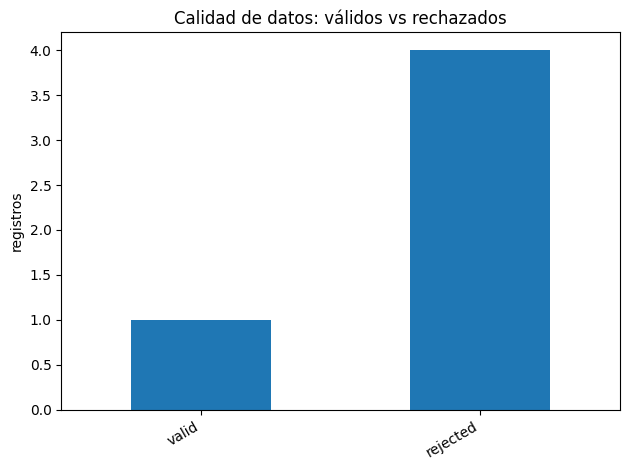

In [5]:
show_bar({"valid": quality_summary["valid"], "rejected": quality_summary["rejected"]},
         "Calidad de datos: válidos vs rechazados", "registros")


## 4. Motivos de rechazo

En la prueba de calidad aparecieron motivos como:

- `missing_field:edad`;
- `sexo:enum`;
- `intensidad_dolor:max:10`.

Estos rechazos se persisten en MongoDB en:

```text
ingestion_rejects
```

In [6]:
reject_reasons = pd.DataFrame([
    {"motivo": "missing_field:edad", "tipo": "campo obligatorio ausente"},
    {"motivo": "sexo:enum", "tipo": "valor no permitido"},
    {"motivo": "intensidad_dolor:max:10", "tipo": "rango inválido"},
])
reject_reasons


,motivo,tipo
0,missing_field:edad,campo obligatorio ausente
1,sexo:enum,valor no permitido
2,intensidad_dolor:max:10,rango inválido


## 5. Eventos de dominio

El pipeline guarda eventos en MongoDB en la colección:

```text
system_events
```

Eventos importantes:

- `pipeline.run.start`;
- `pipeline.file.read`;
- `pipeline.validation.done`;
- `pipeline.transformation.done`;
- `pipeline.loading.done`;
- `pipeline.rejects.persisted`;
- `pipeline.ml.done`;
- `pipeline.run.end`.

Estos eventos alimentan el dashboard, la auditoría y el servicio `automation`.

In [7]:
events = pd.DataFrame([
    {"event": "pipeline.run.start", "level": "info", "descripcion": "inicio de ejecución"},
    {"event": "pipeline.file.read", "level": "info", "descripcion": "CSV leído"},
    {"event": "pipeline.validation.done", "level": "warning/info", "descripcion": "resultado validación"},
    {"event": "pipeline.rejects.persisted", "level": "warning", "descripcion": "rechazos persistidos"},
    {"event": "pipeline.ml.done", "level": "warning/info", "descripcion": "triaje completado o pendiente"},
    {"event": "pipeline.run.end", "level": "info", "descripcion": "fin de ejecución"},
])
events


,event,level,descripcion
0,pipeline.run.start,info,inicio de ejecución
1,pipeline.file.read,info,CSV leído
2,pipeline.validation.done,warning/info,resultado validación
3,pipeline.rejects.persisted,warning,rechazos persistidos
4,pipeline.ml.done,warning/info,triaje completado o pendiente
5,pipeline.run.end,info,fin de ejecución


## 6. Comandos de demostración

Generar CSV sintético:

```powershell
docker compose exec pipeline python main.py seed --n 100 --seed 123
```

Ejecutar batch:

```powershell
docker compose exec pipeline python main.py batch --key "patients/<archivo>.csv"
```

Consultar eventos recientes:

```powershell
docker compose exec mongodb mongosh -u admin -p change-me --authenticationDatabase admin hospital --eval "db.system_events.find().sort({timestamp:-1}).limit(10).pretty()"
```